C:\Users\saram\pynanomat_test



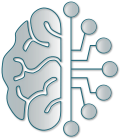

**Start at:** Wednesday 04 March 2026, 14:50:58  
**Hostname:** ordi_sara_mtr (Windows)

<p style="text-align: center"><img width="800px" src="./styles/svg/pyNanoMatBuilder_banner.svg" style="margin-left:auto; margin-right:auto"/></p>

In [1]:
import os
import sys
import tkinter

print(os.getcwd())
cwd0 = './styles/'
sys.path.append(cwd0)

from pathlib import Path
import re
import numpy as np
import pandas as pd
import visualID as vID
from visualID import  fg, hl, bg
vID.init(cwd0)

from pyNanoMatBuilder import crystalNPs as cyNP

from pyNanoMatBuilder import make_files_remastered as mf
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import data
import importlib
from debyecalculator import DebyeCalculator
import pyNanoMatBuilder.utilsDC as pyNMBuDC

# Automated Nanoparticle Structure and Scattering Database Generation

## Overview

This notebook demonstrates how to automatically generate a database of nanoparticle (NP) structures and their corresponding scattering data for all available shapes in pyNanoMatBuilder. The workflow produces structural information and intensity values suitable for machine learning applications. 

---

### Parameters and format

#### Input Parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| **path** | str |  Directory path for generated files |
| **size** | list | Size increment array (multiplier coefficients of dhkl) |
| **max_size** | float |  Maximum NP size, defined as the circumscribed sphere diameter (nm) |
| **cif_data** | dataframe | DataFrame containing CIF files of compounds (pre-defined, extensible) |
| **optimize_structure** | bool | Perform structure optimization using EMT potentiel from ASE, not recommended for batch computation |
| **instance_Debye** | class instance |  Instance of the DebyeCalculator class for computing I(q) and G(r) data. For implementation details, refer to the *DemoUtilsCD.ipynb* notebook. |
| **create_iq** | bool |  Create NPZ files containing Iq data |
| **create_gr** | bool |  Create NPZ files containing Gr data |
| **noOutput** | bool |  Suppress console output |


#### Output Files
- **XYZ/CIF/JMOL**: 3D structural files containing atomic coordinates
- **NPZ**: Optional files containing I(q) and G(r) data (WAXS/SAXS regions separated at ~1.6 Å⁻¹)
- **CSV**: Summary file containing comprehensive NP metadata:
  - Element and crystal structure
  - Shape designation
  - Moments of inertia in the 3 directions (amuÅ⁻2) \
    and moments of inertia with mass normalization (Å⁻2) (mass normalization can be useful to have an idea about the anisotropy)
  - Inscribed/circumscribed diameters (Å)
  - Total number of atoms
  - Wulff construction or not
  - Truncated or not
  - Crystalline state and type
    (state: crystalline/amorphous, type: polycrystalline/monocrystalline/twinned)
  - Shape-specific parameters (e.g., radius, length, wire symmetry)

**File Naming Convention:**  
`compound_lattice_shape_0000001_0000000.extension`  
- First index: size parameter
- Second index: reserved for data augmentation

**Example outputs:**
- ***[XYZ]** NaCl_fcc_cube_0000001_0000000.xyz*
- ***[CIF]** NaCl_fcc_cube_0000001_0000000.cif*
- ***[NPZ]** NaCl_fcc_cube_0000001_0000000_iq.npz*
- ***[CSV]** NaCl_fcc_cube_0000001_0000000_metadata.csv*

**Format Rationale:**  
CSV format ensures accessibility for non-Python users, particularly experimentalists. NPZ format provides lightweight, reusable storage for intensity data. HDF5 implementation is feasible upon request.

---

### Important Notes

**Size Parameter Interpretation:**  
The `size` parameter defines multiplier coefficients of the minimum size increment (typically d(hkl)).

*Examples:*
- Minimum increment: `size = np.arange(2, 150, 1)`  
  Generates sizes from **2×d(hkl)** to **150×d(hkl)** with **1×d(hkl)** steps
  
- Coarser sampling: `size = np.arange(2, 150, 2)`  
  Generates sizes from **2×d(hkl)** to **150×d(hkl)** with **2×d(hkl)** steps

**Structure Validation:**  
pyNanoMatBuilder ensures structural consistency by validating lattice-shape compatibility. Set `noOutput=False` for detailed reporting:
- <span style="color:#008000">**Green**: Successfully created structures (lattice-shape match)</span>
- <span style="color:#FF0000">**Red**: Rejected structures (lattice-shape mismatch)</span>

**Class Organization:**  
Each shape family has a dedicated class, except the crystal family which comprises four classes: Wulff shapes, ellipsoids/parallelepipeds, spheres, and wires.

**Last bugs:**
Sometimes the smallest structure possible does not have the shape defined, develepment ongoing. 

## 1. Crystals

### 1. Wulff shapes

In [2]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path = "coords"

# Sizes of the NPs
# 1. Size increment
size = np.arange(2, 150, 1) # size is a multiplier coefficient of dhkl, so the final sizes are : 2*dhkl, 3*dhkl, ..., 150*dhkl
# 2. Maximum size
max_size = 2 # circumsphere diameter in nm, if not defined, it will be = 150*dhkl

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda') # replace per "cpu" if you don't have a GPU available
instance_Debye = DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
# If max_size isn't defined, the NPs will have the size given by the increment (by multiple of dhkl).
class_test= mf.PredefinedWulffFiles(path, # path of the files
                                    cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                                    wulff_shapes=data.WulffShapes.WSdf, # pre-defined Wulff shapes
                                    sizes=size, max_size = max_size, # size increment and maximum size
                                    optimize_structure = False, # optimize all the structures using EMT from ASE 
                                    instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                                    create_iq = True, # if you want Iq
                                    create_gr = False, # if you want Gr
                                    noOutput= False) 

print(t.chrono_stop(hdelay=True))


                         NaCl                       

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1000041-NaCl.cif
 d_hkl = 0.5620 nm 

  fcc ∈ ['bcc', 'fcc'] → Wulff form: cube 



C:\Users\saram\anaconda3\envs\debyecalculator_env\Lib\site-packages\ase\io\cif.py:401: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(225, setting=1). This may result in wrong setting!
  warnings.warn(
C:\Users\saram\anaconda3\envs\debyecalculator_env\Lib\site-packages\ase\io\cif.py:401: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(225, setting=1). This may result in wrong setting!
  warnings.warn(


 Generating size is 1.1240 nm (dhkl × [2]).
 Circumscribed sphere diameter = 1.95 nm
[XYZ] Writing file: coords\NaCl_fcc_cube_0000001_0000000.xyz
[CIF] Writing file: coords\NaCl_fcc_cube_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\NaCl_fcc_cube_0000001_0000000_iq.npz
[CSV] Saved metadata: coords\NaCl_fcc_cube_0000001_0000000_metadata.csv
 Circumscribed sphere diameter = 2.92 nm > max = 2 nm → skipped.

  fcc ∈ ['fcc'] → Wulff form: trcube 

 Generating size is 1.1240 nm (dhkl × [2]).
 Circumscribed sphere diameter = 1.59 nm
[XYZ] Writing file: coords\NaCl_fcc_trcube_0000001_0000000.xyz
[CIF] Writing file: coords\NaCl_fcc_trcube_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\NaCl_fcc_trcube_0000001_0000000_iq.npz
[CSV] Saved metadata: coords\NaCl_fcc_trcube_0000001_0000000_metadata.csv
 Circumscribed sphere diameter = 2.45 nm > max = 2 nm → skipped.

  fcc ∈ ['fcc'] → Wulff form: cubo 

 Generating size is 1.1240 nm (dhkl × [2]).
 Circumscribed sphere diameter = 1.59 nm
[XYZ] W

C:\Users\saram\anaconda3\envs\debyecalculator_env\Lib\site-packages\ase\io\cif.py:401: UserWarning: crystal system 'tetragonal' is not interpreted for space group Spacegroup(141, setting=1). This may result in wrong setting!
  warnings.warn(
C:\Users\saram\anaconda3\envs\debyecalculator_env\Lib\site-packages\ase\io\cif.py:401: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(229, setting=1). This may result in wrong setting!
  warnings.warn(


 Generating size is 0.8582 nm (dhkl × [3]).
 Circumscribed sphere diameter = 1.49 nm
[XYZ] Writing file: coords\Fe_bcc_cube_0000002_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_cube_0000002_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_cube_0000002_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_cube_0000002_0000000_metadata.csv
 Generating size is 1.1443 nm (dhkl × [4]).
 Circumscribed sphere diameter = 1.98 nm
[XYZ] Writing file: coords\Fe_bcc_cube_0000003_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_cube_0000003_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_cube_0000003_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_cube_0000003_0000000_metadata.csv
 Circumscribed sphere diameter = 2.48 nm > max = 2 nm → skipped.
  bcc ∉ ['fcc'] for Wulff form: trcube 
  bcc ∉ ['fcc'] for Wulff form: cubo 
  bcc ∉ ['fcc'] for Wulff form: Oh 
  bcc ∉ ['fcc'] for Wulff form: trOh 
  bcc ∉ ['fcc'] for Wulff form: Td 
  bcc ∉ ['fcc'] for Wulff form: dicoTd 

  bcc ∈ ['bcc'] → Wulff form: 

### 2. Ellipsoids and parallepipeds

In [3]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords' 

# Sizes of the NPs
# 1. Size increment (will also define the shape of the ellipsoid and/or parallelepiped here !)
# Array of the 3 lengths of the ellipsoid/parallelepiped, d is a multiplier coefficient of dhkl
size = [[d, 0.5*d, 1.5*d] for d in np.arange(2, 150,1)] # a, b=a/2, c = 1.5*a

# 2. Maximum size
max_size = 2 # circumsphere diameter in nm

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test=mf.Crystals_EllipsoidsParallelepipeds(path, # path of the files
                                              cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds  
                                              forms=['ellipsoid','parallelepiped'], # you can either both, or one of them
                                              sizes=size, max_size= max_size, # size increment and maximum size
                                              optimize_structure = False, # optimize the structures using EMT from ASE 
                                              instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                                              create_iq = True, # if you want Iq
                                              create_gr = True,  # if you want Gr
                                              noOutput= False) 
print(t.chrono_stop(hdelay=True))



                        NaCl                        

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1000041-NaCl.cif
 d_hkl = 0.5620 nm 

 Shape: ellipsoid 

 Generating size: [1.124, 0.562, 1.6860000000000002] nm (dhkl × [2, 1.0, 3.0])
 Circumscribed sphere diameter: 0.84 nm
[XYZ] Writing file: coords\NaCl_fcc_ellipsoid_0000001_0000000.xyz
[CIF] Writing file: coords\NaCl_fcc_ellipsoid_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\NaCl_fcc_ellipsoid_0000001_0000000_iq.npz
[NPZ] Saved g(r) data: coords\NaCl_fcc_ellipsoid_0000001_0000000_gr.npz
[CSV] Saved metadata: coords\NaCl_fcc_ellipsoid_0000001_0000000_metadata.csv
[SASVIEW] Saved: coords\NaCl_fcc_ellipsoid_0000001_0000000_metadata_sasview.csv
 Generating size: [1.6860000000000002, 0.8430000000000001, 2.5290000000000004] nm (dhkl × [3, 1.5, 4.5])
 Circumscribed sphere diameter: 1.97 nm
[XYZ] Writing file: coords\NaCl_fcc_ellipsoid_0000002_0000000.xyz
[CIF] Writing file: coords\NaCl_fcc_ellipsoid_0000002_00

### 3. Spheres

In [4]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
size = [[d] for d in np.arange(2, 150, 1)]  

# 2. Maximum size
max_size = 2 # circumsphere diameter in nm

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test=mf.Crystals_spheres(path, # path of the files
                               cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds  
                               sizes=size, max_size= max_size, # size increment and maximum size
                               optimize_structure = False, # optimize the structures using EMT from ASE 
                               instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                               create_iq = False, # if you want Iq
                               create_gr = False,  # if you want Gr
                               noOutput = False) 

print(t.chrono_stop(hdelay=True))



                       NaCl                       

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1000041-NaCl.cif
 d_hkl = 0.562 nm 
 Generating sphere of size 1.12 nm (dhkl × 2) 
 Circumscribed diameter = 0.84 nm 
[XYZ] Writing file: coords\NaCl_fcc_sphere_0000001_0000000.xyz
[CIF] Writing file: coords\NaCl_fcc_sphere_0000001_0000000.cif
[CSV] Saved metadata: coords\NaCl_fcc_sphere_0000001_0000000_metadata.csv
[SASVIEW] Saved: coords\NaCl_fcc_sphere_0000001_0000000_metadata_sasview.csv
 Generating sphere of size 1.69 nm (dhkl × 3) 
 Circumscribed diameter = 1.41 nm 
[XYZ] Writing file: coords\NaCl_fcc_sphere_0000002_0000000.xyz
[CIF] Writing file: coords\NaCl_fcc_sphere_0000002_0000000.cif
[CSV] Saved metadata: coords\NaCl_fcc_sphere_0000002_0000000_metadata.csv
[SASVIEW] Saved: coords\NaCl_fcc_sphere_0000002_0000000_metadata_sasview.csv
 Generating sphere of size 2.25 nm (dhkl × 4) 
 Circumscribed diameter = 1.97 nm 
[XYZ] Writing file: coords\NaCl_fcc_sphere_

### 4. Wires (4 and 6 symetry)

In [5]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
# d is a multiplier coefficient of dhkl
size = [[0.25*d, d] for d in np.arange(8, 150, 1)] # here [diameter, length] with diameter = length/4
# 2. Maximum size
max_size = 6 # circumsphere diameter in nm

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test= mf.Crystals_wires(path, # path of the files
                              cif_data=data.pyNMBcif.CIFdf,  # pre-defined compounds
                              sizes=size, max_size= max_size, # size increment and maximum size
                              optimize_structure = False, # optimize the structures using EMT from ASE 
                              instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                              create_iq = False, # if you want Iq
                              create_gr = False,  # if you want Gr
                              noOutput= False) 


                        Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
refPlaneWire=[0, 1, -1] and directionWire=[1, 1, 1]

d_hkl_length is 0.16516836500976814 nm
d_hkl_diameter is 0.20228910796184751 nm

 nRot (cross section of the wire) =4

 Generating size is [0.40457821592369503, 1.3213469200781451] nm and is equal to dhkl multiplied by [2.0, 8]. 
  Circumscribed sphere diameter =1.4015000512308229 nm 
[XYZ] Writing file: coords\Fe_bcc_wire4_0000001_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_wire4_0000001_0000000.cif
[CSV] Saved metadata: coords\Fe_bcc_wire4_0000001_0000000_metadata.csv
 Generating size is [0.4551504929141569, 1.4865152850879133] nm and is equal to dhkl multiplied by [2.25, 9]. 
  Circumscribed sphere diameter =1.4865152850879129 nm 
[XYZ] Writing file: coords\Fe_bcc_wire4_0000002_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_wire4_0000002_0000000.cif
[CSV] Saved metadata: coords\Fe_bcc_wire4

## 2. Johnson

### 1. Fcctbp
**Rimender for the fcc trigonal bipyramid**

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of atomic layers in **one** tetrahedral pyramid. The full bipyramid has **2 × nLayerTd** layers (top + bottom). |

In [6]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Sizes
# 1. Size increment
# d is a multiplier coefficient of dhkl
sizes = np.arange(1,150,1) # nLayerTd
# 2. Maximum size 
max_size = 2 # circumsphere diameter in nm

# Instance of the class
class_test=mf.Johnson_Files(path,
                            cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                            sizes=sizes, max_size= max_size, # size increment and maximum size 
                            mode='fcctbp',
                            optimize_structure = False,  # optimize the structures using EMT from ASE 
                            instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                            create_iq = True,  # if you want Iq
                            create_gr = False, # if you want Gr
                            noOutput= False) 

print(t.chrono_stop(hdelay=True))


                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
 xyz/cif files can't be created for Fe bcc because the crystal type isn't fcc.

                     Mn alpha                     

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9011068-Mn_alpha.cif
 xyz/cif files can't be created for Mn alpha because the crystal type isn't fcc.

                     Mn beta                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1539039-Mn_beta.cif
 xyz/cif files can't be created for Mn beta because the crystal type isn't fcc.

                      Co hcp                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9008492-Co_hcp.cif
 xyz/cif files can't be created for Co hcp because the crystal type isn't fcc.

                      Co fcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\

C:\Users\saram\pynanomat_test\pyNanoMatBuilder\platonicNPs.py:1227: RuntimeWarning: invalid value encountered in scalar divide
  return self.heightOfPyramid() / (self.nLayer - 1)


Circumscribed sphere diameter =0.4096877510169584
[XYZ] Writing file: coords\Co_fcc_fcctbp_0000001_0000000.xyz
[CIF] Writing file: coords\Co_fcc_fcctbp_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\Co_fcc_fcctbp_0000001_0000000_iq.npz
[CSV] Saved metadata: coords\Co_fcc_fcctbp_0000001_0000000_metadata.csv
Number of bonds is 2
Circumscribed sphere diameter =0.8193755020339168
[XYZ] Writing file: coords\Co_fcc_fcctbp_0000002_0000000.xyz
[CIF] Writing file: coords\Co_fcc_fcctbp_0000002_0000000.cif
[NPZ] Saved I(q) data: coords\Co_fcc_fcctbp_0000002_0000000_iq.npz
[CSV] Saved metadata: coords\Co_fcc_fcctbp_0000002_0000000_metadata.csv
Number of bonds is 3
Circumscribed sphere diameter =1.2290632530508756
[XYZ] Writing file: coords\Co_fcc_fcctbp_0000003_0000000.xyz
[CIF] Writing file: coords\Co_fcc_fcctbp_0000003_0000000.cif
[NPZ] Saved I(q) data: coords\Co_fcc_fcctbp_0000003_0000000_iq.npz
[CSV] Saved metadata: coords\Co_fcc_fcctbp_0000003_0000000_metadata.csv
Number of bonds is 4
Circ

### 2. EpbpyM
**2. Reminder for the pentagonal bipyramids, including elongated and truncated variants**

Size parameters:

| Parameter | Meaning |
|---|---|
| **sizeP** | Number of layers in the pentagonal cross-section (equivalently, number of bonds per pentagonal edge). |
| **sizeE** | Number of layers along the elongated height direction (number of bonds per elongated edge). |
| **Marks** | Truncation depth per pentagonal edge, expressed as number of atoms removed. The total truncation at a full vertex is **2 × Marks**. |



In [7]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# 1. Size increment
# An example of possible combinations of sizes
sizeP = np.arange(1, 150, 3)  # Size of the pentagonal cap
sizeE = np.arange(1, 50, 5)  # Size of the elongated part
Marks = np.arange(0, 1, 1)  # Marks truncation at the vertices

# Compute the valid combinations (because of geometric conditions, e.g. Marks truncation < size of the pentagonal cap)
from itertools import product
valid_combinations = [(p, e, m) for p, e, m in product(sizeP, sizeE, Marks) if m <= (p-1) // 2]
valid_combinations = np.array(valid_combinations)
print("Valid combinations:", valid_combinations)

# 2. Maximum size 
max_size = 2 # circumsphere diameter in nm

# Instance of the class
class_test=mf.Johnson_Files(path,
                            cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                            sizes=valid_combinations, max_size=2, # size increment and maximum size 
                            mode='epbpyM',
                            optimize_structure = True, # optimize the structures using EMT from ASE
                            instance_Debye = instance_Debye,  # if you want to compute Iq/Gr
                            create_iq = True, # if you want Iq
                            create_gr = False, # if you want Gr
                            noOutput= False) 


print(t.chrono_stop(hdelay=True))

Valid combinations: [[  1   1   0]
 [  1   6   0]
 [  1  11   0]
 ...
 [148  36   0]
 [148  41   0]
 [148  46   0]]
 Sizes = [bonds in pentagonal cross-section, elongated part, number of truncated atoms]

                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
 [1,1,0]  
Circumscribed sphere diameter =0.5210048893409063
[XYZ] Writing file: coords\Fe_bcc_epbpyM_0000001_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_epbpyM_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_epbpyM_0000001_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_epbpyM_0000001_0000000_metadata.csv
 [1,6,0]  
Circumscribed sphere diameter =1.8235171126931722
[XYZ] Writing file: coords\Fe_bcc_epbpyM_0000002_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_epbpyM_0000002_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_epbpyM_0000002_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_epbpyM_0000002_0000000_metadata.csv
 [1,11,0]  


N atoms: 13
Positions range: min [-1.9055242  -2.24007804 -2.91138191]  max [2.35535744 2.24007804 2.91138191]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.7689 Å, dmean=3.8115 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
*Force-consistent energies used in optimization.
BFGSLineSearch:    0[  0] 14:52:58       13.106186*       3.5681
BFGSLineSearch:    1[  2] 14:52:58        9.774262*       0.7607
BFGSLineSearch:    2[  3] 14:52:58        9.584895*       0.4021
BFGSLineSearch:    3[  5] 14:52:58        9.495694*       0.6237
BFGSLineSearch:    4[  6] 14:52:58        9.458238*       0.1867
BFGSLineSearch:    5[  7] 14:52:58        9.455708*       0.0136
Optimization steps saved in coords\Pt_fcc_epbpyM_0000001_0000000_.opt (binary file)
Optimized geometry saved in coords\Pt_fcc_epbpyM_0000001_0000000_opt.xyz
Duration : 00:00:00 373ms
[CIF] Writing file: coords\Pt_fcc_epbpyM_0000001_00000

N atoms: 13
Positions range: min [-1.98457635 -2.33300942 -3.03216284]  max [2.45307127 2.33300942 3.03216284]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.8838 Å, dmean=3.9696 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
*Force-consistent energies used in optimization.
BFGSLineSearch:    0[  0] 14:52:58       10.113512*       2.5319
BFGSLineSearch:    1[  1] 14:52:58        7.114969*       0.6641
BFGSLineSearch:    2[  2] 14:52:58        7.016697*       0.2192
BFGSLineSearch:    3[  3] 14:52:58        6.973217*       0.2663
BFGSLineSearch:    4[  5] 14:52:58        6.940011*       0.2155
BFGSLineSearch:    5[  6] 14:52:58        6.915528*       0.0695
Optimization steps saved in coords\Au_fcc_epbpyM_0000001_0000000_.opt (binary file)
Optimized geometry saved in coords\Au_fcc_epbpyM_0000001_0000000_opt.xyz
Duration : 00:00:00 087ms
[CIF] Writing file: coords\Au_fcc_epbpyM_0000001_00000

N atoms: 13
Positions range: min [-1.98844501 -2.3375573  -3.03807364]  max [2.4578532  2.3375573  3.03807364]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.8894 Å, dmean=3.9774 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
*Force-consistent energies used in optimization.
BFGSLineSearch:    0[  0] 14:52:58        8.099760*       1.1495
BFGSLineSearch:    1[  1] 14:52:58        7.229461*       0.2885
BFGSLineSearch:    2[  2] 14:52:58        7.152982*       0.2180
BFGSLineSearch:    3[  3] 14:52:58        7.099499*       0.1701
BFGSLineSearch:    4[  5] 14:52:58        7.072908*       0.1935
BFGSLineSearch:    5[  6] 14:52:58        7.066603*       0.0983
Optimization steps saved in coords\Ag_fcc_epbpyM_0000001_0000000_.opt (binary file)
Optimized geometry saved in coords\Ag_fcc_epbpyM_0000001_0000000_opt.xyz
Duration : 00:00:00 089ms
[CIF] Writing file: coords\Ag_fcc_epbpyM_0000001_00000

## 3. Catalans

**Reminder of the size parameter for the catalan solids**

The **bcc rhombic dodecahedron** and **fcc dihedral rhombic dodecahedron** are constructed using a size parameter that defines the extent of the structure:

| Parameter | Description |
|-----------|-------------|
| **nShell** |  Number of concentric shells built outward from the center  |


In [8]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
sizes=np.arange(1,150,1) # Control the sizes by the number of shells (bonds per edges) : here 1 to 150 bonds (step of 1)
# 2. Maximum size 
max_size = 2 # circumsphere diameter in nm

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda :True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test = mf.Catalan_Files(path,  # path of the files
                              cif_data=data.pyNMBcif.CIFdf,  # pre-defined compounds
                              sizes=sizes, max_size= max_size, # size increment and maximum size 
                              optimize_structure= False, # optimize the structures using EMT from ASE
                              instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                              create_iq = True, # if you want Iq
                              create_gr = False, # if you want Gr
                              noOutput= False) 


print(t.chrono_stop(hdelay=True))



                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
 xyz/cif files can be created for Fe bcc with Bravais lattice = bcc. 
 Number of atoms per edge is 2
Circumscribed sphere diameter = 0.572 nm
[XYZ] Writing file: coords\Fe_bcc_bccrDD_0000001_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_bccrDD_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_bccrDD_0000001_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_bccrDD_0000001_0000000_metadata.csv
 Number of atoms per edge is 3
Circumscribed sphere diameter = 1.144 nm
[XYZ] Writing file: coords\Fe_bcc_bccrDD_0000002_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_bccrDD_0000002_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_bccrDD_0000002_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_bccrDD_0000002_0000000_metadata.csv
 Number of atoms per edge is 4
Circumscribed sphere diameter = 1.716 nm
[XYZ] Writing file: coords\Fe_bcc_bccrDD_0000003_000

## 4. Platonic 

**The platonic module is dedicated to magic number structures: regular icosahedrons, tetrahedrons, octahedrons, dodecahedrons, and cubes.**



**Size Parameters by Shape**

| Parameter | Shapes | Description |
|-----------|--------|-------------|
| **nOrder** | Octahedron, Cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Icosahedron, Dodecahedron | Number of concentric shells built outward from the center |
| **nLayer** | Tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |

The distinction reflects different construction principles: **nOrder** represents structures built as nested polyhedra (like Russian dolls), while **nShell** describes structures grown layer-by-layer from a central core. Both **nOrder** and **nShell** correspond to the number of atomic layers along an edge, but their conceptual frameworks differ based on the geometric construction.

*Note: Standard platonic structures are fully implemented with accurate structural information. Specialized variants (double icosahedrons and tetrahedral helices) are functional but provide approximate dimensional data—these features are under active development.*

In [9]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
sizes=np.arange(1,150,1) # Control the sizes by the number of bonds per edges : here 1 to 150 bonds (step of 1)
# 2. Maxmimum size
max_size = 2

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test=mf.Platonic_Files(path,  # path of the files
                            cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                            sizes=sizes, max_size= max_size, # size increment and maximum size 
                            optimize_structure = False, # optimize the structures using EMT from ASE
                            instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                            create_iq = True,  # if you want Iq
                            create_gr = False, # if you want Gr
                            noOutput= False) # Ex: the maximal size is a circumsphere diameter of 5 nm.


print(t.chrono_stop(hdelay=True))


                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
  The forms possible of Fe bcc(bcc) are ['regDD', 'regIco', 'cube'].
  xyz/cif files can be created for Fe bcc of Bravais lattice=bcc for the form regDD. 
 Number of bonds is 1
Circumscribed sphere diameter =0.6943307452523548
[XYZ] Writing file: coords\Fe_bcc_regDD_0000001_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_regDD_0000001_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_regDD_0000001_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_regDD_0000001_0000000_metadata.csv
 Number of bonds is 2
Circumscribed sphere diameter =1.3886614905047097
[XYZ] Writing file: coords\Fe_bcc_regDD_0000002_0000000.xyz
[CIF] Writing file: coords\Fe_bcc_regDD_0000002_0000000.cif
[NPZ] Saved I(q) data: coords\Fe_bcc_regDD_0000002_0000000_iq.npz
[CSV] Saved metadata: coords\Fe_bcc_regDD_0000002_0000000_metadata.csv
 Number of bonds is 3
 Size greater than the ci

## 5. Archimedean

**Reminder for the Archimedean solids**

This class uses the `platonicNPs` module to generate the parent structures, then applies a truncation of ~33% (chosen to approximate more stable shapes).  
As a result, the size parameters follow the same definitions as in the Platonic classes.

**Size parameters (same convention as Platonic NPs)**

| Parameter | Shape(s) | Meaning |
|---|---|---|
| **nOrder** | Truncated octahedron, truncated cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Cuboctahedron | Number of concentric shells built outward from the center |
| **nLayer** | Truncated tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |

*Note: To lead to a perfect truncature, the increment is must be 3n for nOrder and nLayer, for nShell it's n directly. Just follow the default increment given by the notebook, or a multiple.*

### 1.FccTrOh

In [10]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
sizes=np.arange(3,25,3) # Control the sizes by nOrder, 3n for good truncation
# 2. Maxmimum size
max_size = 2

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : False
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test= mf.ArchimedeansFiles(path, # path of the files
                                 cif_data=data.pyNMBcif.CIFdf,  # pre-defined compounds
                                 sizes=sizes, max_size= max_size, # size increment and maximum size 
                                 mode = 'fccTrOh',
                                 optimize_structure = False, # optimize the structures using EMT from ASE
                                 instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                                 create_iq = True, # if you want Iq
                                 create_gr = True, # if you want Gr
                                 noOutput= False) 

print(t.chrono_stop(hdelay=True))


C:\Users\saram\AppData\Local\Temp\ipykernel_32968\2430479142.py:16: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  instance_Debye = DebyeCalculator(device='cuda')
C:\Users\saram\AppData\Local\Temp\ipykernel_32968\2430479142.py:17: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)



                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
  xyz/cif files can't be created for Fe bcc because the crystal type isn't fcc.

                     Mn alpha                     

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9011068-Mn_alpha.cif
  xyz/cif files can't be created for Mn alpha because the crystal type isn't fcc.

                     Mn beta                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1539039-Mn_beta.cif
  xyz/cif files can't be created for Mn beta because the crystal type isn't fcc.

                      Co hcp                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9008492-Co_hcp.cif
  xyz/cif files can't be created for Co hcp because the crystal type isn't fcc.

                      Co fcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_datab

### 2. fccTrCube

In [11]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
sizes=np.arange(3,25,3) # Control the sizes by nOrder, 3n for good truncation
# 2. Maximum size
max_size = 2

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : False
instance_Debye = DebyeCalculator(device='cpu')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test= mf.ArchimedeansFiles(path, # path of the files
                                 cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                                 sizes=sizes, max_size= 1.5,  # size increment and maximum size 
                                 mode = 'fccTrCube',
                                 optimize_structure = False, # optimize the structures using EMT from ASE
                                 instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                                 create_iq = True, # if you want Iq
                                 create_gr = True, # if you want Gr
                                 noOutput= False) 

print(t.chrono_stop(hdelay=True))

C:\Users\saram\AppData\Local\Temp\ipykernel_32968\3742936422.py:17: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)



                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
  xyz/cif files can't be created for Fe bcc because the crystal type isn't fcc.

                     Mn alpha                     

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9011068-Mn_alpha.cif
  xyz/cif files can't be created for Mn alpha because the crystal type isn't fcc.

                     Mn beta                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1539039-Mn_beta.cif
  xyz/cif files can't be created for Mn beta because the crystal type isn't fcc.

                      Co hcp                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9008492-Co_hcp.cif
  xyz/cif files can't be created for Co hcp because the crystal type isn't fcc.

                      Co fcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_datab

### 3. fccTrTd

In [12]:
#t = pyNMBu.timer()
#t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
sizes=np.arange(4,150,3) # Control the sizes by nLayer, 3n for good truncation
# 2. Maximum size
max_size = 2

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test= mf.ArchimedeansFiles(path, # path of the files
                                 cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                                 sizes=sizes, max_size= 2,  # size increment and maximum size 
                                 mode = 'fccTrTd',
                                 optimize_structure= False, # optimize the structures using EMT from ASE
                                 instance_Debye = instance_Debye, # if you want to compute Iq/Gr
                                 create_iq = True, # if you want Iq
                                 create_gr = False, # if you want Gr
                                 noOutput= False) 

print(t.chrono_stop(hdelay=True))


                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
  xyz/cif files can't be created for Fe bcc because the crystal type isn't fcc.

                     Mn alpha                     

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9011068-Mn_alpha.cif
  xyz/cif files can't be created for Mn alpha because the crystal type isn't fcc.

                     Mn beta                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1539039-Mn_beta.cif
  xyz/cif files can't be created for Mn beta because the crystal type isn't fcc.

                      Co hcp                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9008492-Co_hcp.cif
  xyz/cif files can't be created for Co hcp because the crystal type isn't fcc.

                      Co fcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_datab

### 4. fccCubo

In [13]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# Sizes of the NPs
# 1. Size increment
sizes=np.arange(1,25,1)  # Control the sizes by nShells = the number of bonds per edges 
# 2. Maximum size
max_size = 2

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : False
instance_Debye = DebyeCalculator(device='cpu')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)

# Instance of the class
class_test= mf.ArchimedeansFiles(path, # path of the files
                                 cif_data=data.pyNMBcif.CIFdf, # pre-defined compounds
                                 sizes=sizes,  max_size= 2, # size increment and maximum size 
                                 mode = 'fccCubo',
                                 optimize_structure= False, # optimize the structures using EMT from ASE
                                 instance_Debye = instance_Debye,  # if you want to compute Iq/Gr
                                 create_iq = True, # if you want Iq
                                 create_gr = True, # if you want Gr
                                 noOutput= False) 


print(t.chrono_stop(hdelay=True))

C:\Users\saram\AppData\Local\Temp\ipykernel_32968\2022684154.py:17: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)



                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
  xyz/cif files can't be created for Fe bcc because the crystal type isn't fcc.

                     Mn alpha                     

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9011068-Mn_alpha.cif
  xyz/cif files can't be created for Mn alpha because the crystal type isn't fcc.

                     Mn beta                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1539039-Mn_beta.cif
  xyz/cif files can't be created for Mn beta because the crystal type isn't fcc.

                      Co hcp                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9008492-Co_hcp.cif
  xyz/cif files can't be created for Co hcp because the crystal type isn't fcc.

                      Co fcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_datab

## 6. OtherNPs

For now, only the platelet exists. It is built by adding two truncated tetrahedrons to create a bipyramid, then potentially adding shells between the two pyramids.

**Reminder of the size parameter**:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of layers (bonds per edge) of the two tetrahedrons used to create the platelet. This value will define the edge length of the final platelet; the number of layers of the platelet will be `nLayerTd + 1`. |
| **nLayer** | The number of layers kept for each tetrahedron (not counting the twin plane). This value will define the thickness of the platelet; the number of layers in the final platelet will be `nLayer * 2`. |

In [14]:
t = pyNMBu.timer()
t.chrono_start()

# Path where the files are created
path='coords'

# If you want to create NPZ files containing Iq/Gr, you need to make an instance of the Debye class 
import torch
torch.cuda.is_available = lambda : True
instance_Debye = DebyeCalculator(device='cuda')
instance_Debye=DebyeCalculator(qmin=0.001, qmax=20.0, qstep=0.001, qdamp=0.0, biso=0.0)


# Sizes of the platelet
# 1. Size increment
sizes=np.arange(3,150,1) # nLayerTd
sizes2=np.arange(1,50,1) # nLayer
# 2. Maximum size
max_size = 2

# Instance of the class
class_test=mf.OtherNPs_Files(path,
                             cif_data=data.pyNMBcif.CIFdf,
                             sizes=sizes, sizes2=sizes2, max_size=max_size,
                             optimize_structure=  False, 
                             instance_Debye = instance_Debye,
                             create_iq = True,
                             create_gr = False,
                             noOutput= False) 

print(t.chrono_stop(hdelay=True))


                      Fe bcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod5000217-Fe_bcc.cif
  xyz/cif files can't be created for Fe bcc because the crystal type isn't fcc.  

                     Mn alpha                     

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9011068-Mn_alpha.cif
  xyz/cif files can't be created for Mn alpha because the crystal type isn't fcc.  

                     Mn beta                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod1539039-Mn_beta.cif
  xyz/cif files can't be created for Mn beta because the crystal type isn't fcc.  

                      Co hcp                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\cif_database\cod9008492-Co_hcp.cif
  xyz/cif files can't be created for Co hcp because the crystal type isn't fcc.  

                      Co fcc                      

Absolute path to CIF: C:\Users\saram\pynanomat_test\c

# Make a dataframe of all the data : usable for ML applications

#### If you want to take a look at the content of the NPZ intensity file

In [15]:
############################### Iq NPZ file ###################################
data_iq = np.load("coords/Pt_fcc_trOh_0000001_0000000_iq.npz") # Path of your Iq NPZ file
q = data_iq['q']
iq_saxs = data_iq['iq_saxs']
iq_waxs = data_iq['iq_waxs']

print("-------------------- Iq NPZ file content --------------------")
print('q =',q)
print("len(q)",len(q))
print('iq_saxs =',iq_saxs)
print('iq_saxs length =', len(iq_saxs))
print('iq_waxs =',iq_waxs)
print('iq_waxs length =', len(iq_waxs))
print("len(iq_waxs + iq_saxs)",len(iq_waxs) + len(iq_saxs))
print('')
print('')

############################### Gr NPZ file ###################################
data_iq = np.load("coords/Ag_fcc_fccCubo_0000002_0000000_gr.npz")  # Path of your Gr NPZ file
r = data_iq['r']
g  = data_iq['gr']

print("-------------------- Gr NPZ file content --------------------")
print('r =',r)
print("len(r)",len(r))
print('g = ', g)
print('g length =', len(g))


-------------------- Iq NPZ file content --------------------
q = [1.0000e-03 2.0000e-03 3.0000e-03 ... 1.9997e+01 1.9998e+01 1.9999e+01]
len(q) 19999
iq_saxs = [1097164.    1097152.8   1097135.2   ...   13436.141   13380.031
   13323.875]
iq_saxs length = 1599
iq_waxs = [13267.633 13211.32  13154.93  ...  2726.91   2726.441  2725.973]
iq_waxs length = 18400
len(iq_waxs + iq_saxs) 19999


-------------------- Gr NPZ file content --------------------
r = [0.000e+00 1.000e-02 2.000e-02 ... 1.997e+01 1.998e+01 1.999e+01]
len(r) 2000
g =  [ 0.         -0.02927567 -0.05746016 ...  0.04135351  0.03751899
  0.032195  ]
g length = 2000


#### Make the final dataframe

In [16]:
csv_folder_path = "coords"
# base_npz_path = "coords"
df_complete = mf.create_full_dataframe_from_csv_npz(csv_folder_path,
                                                base_npz_path=None) # if you don't give the NPZ path, it will be the same as the csv folder
print(df_complete.columns)
df_complete

Index(['id', 'element', 'crystal_structure', 'shape', 'MOI_1_amuA2',
       'MOI_2_amuA2', 'MOI_3_amuA2', 'MOInorm_1_A2', 'MOInorm_2_A2',
       'MOInorm_3_A2', 'circumradius_A', 'inradius_A', 'truncated',
       'number_of_atoms', 'wulff', 'state', 'type', 'wire_nRot',
       'wire_plane_rotated', 'wire_length', 'wire_radius', 'q', 'iq_saxs',
       'iq_waxs', 'r', 'gr'],
      dtype='object')


,id,element,crystal_structure,shape,MOI_1_amuA2,MOI_2_amuA2,MOI_3_amuA2,MOInorm_1_A2,MOInorm_2_A2,MOInorm_3_A2,...,type,wire_nRot,wire_plane_rotated,wire_length,wire_radius,q,iq_saxs,iq_waxs,r,gr
0,Ag_fcc_cube_0000001_0000000,Ag,fcc,cube,5.963,5.963,5.963,5.963,5.963,5.963,...,monocrystalline,NaN,NaN,NaN,NaN,"[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.0...","[216483.03, 216481.05, 216477.72, 216473.02, 2...","[4835.9575, 4836.54, 4837.1055, 4837.646, 4838...",no data,no data
1,Ag_fcc_cube_0000002_0000000,Ag,fcc,cube,16.962,16.962,16.962,16.962,16.962,16.962,...,monocrystalline,NaN,NaN,NaN,NaN,"[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.0...","[4383757.0, 4383644.0, 4383456.0, 4383193.5, 4...","[11272.746, 11251.836, 11230.648, 11209.16, 11...",no data,no data
2,Ag_fcc_cubo_0000001_0000000,Ag,fcc,cubo,14.572,14.572,14.572,14.572,14.572,14.572,...,monocrystalline,NaN,NaN,NaN,NaN,"[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.0...","[3341114.0, 3341039.8, 3340917.0, 3340744.0, 3...","[6262.504, 6253.3555, 6244.246, 6235.1562, 622...",no data,no data
3,Ag_fcc_cubo_0000002_0000000,Ag,fcc,cubo,28.623,28.623,28.623,28.623,28.623,28.623,...,monocrystalline,NaN,NaN,NaN,NaN,"[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.0...","[23866978.0, 23865952.0, 23864238.0, 23861828....","[11500.297, 11473.844, 11447.227, 11421.1875, ...",no data,no data
4,Ag_fcc_dicoTd_0000001_0000000,Ag,fcc,dicoTd,7.030,7.030,7.030,7.030,7.030,7.030,...,monocrystalline,NaN,NaN,NaN,NaN,"[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.0...","[398726.2, 398721.78, 398714.6, 398704.6, 3986...","[3270.1133, 3249.873, 3229.6797, 3209.5283, 31...",no data,no data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,TiO2_rutile_sphere_0000002_0000000,TiO2,tetragonal,sphere,7.678,8.234,8.428,7.638,7.848,8.231,...,monocrystalline,NaN,NaN,NaN,NaN,no data,no data,no data,no data,no data
561,TiO2_rutile_sphere_0000003_0000000,TiO2,tetragonal,sphere,12.979,14.217,14.499,13.471,13.856,14.454,...,monocrystalline,NaN,NaN,NaN,NaN,no data,no data,no data,no data,no data
562,TiO2_rutile_sphere_0000004_0000000,TiO2,tetragonal,sphere,20.279,21.105,21.902,20.829,20.975,21.742,...,monocrystalline,NaN,NaN,NaN,NaN,no data,no data,no data,no data,no data
563,TiO2_rutile_sphere_0000005_0000000,TiO2,tetragonal,sphere,31.348,31.593,32.498,31.095,31.631,32.602,...,monocrystalline,NaN,NaN,NaN,NaN,no data,no data,no data,no data,no data


#### Save the dataframe as a CSV file

In [19]:
df_complete.to_csv("coords/final_database.csv")

#### For later: recreate the dataframe from the CSV file

In [22]:
import pandas as pd

# Lecture du fichier CSV
df = pd.read_csv("coords/final_database.csv")
# df